In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [2]:
preprocessor = joblib.load("preprocessor.pkl")

random_forest = joblib.load("random_forest_model.pkl")

decision_threshold = joblib.load("decision_threshold.pkl")

X_test_processed = joblib.load("X_test_processed.pkl")
y_test = joblib.load("y_test.pkl")

In [3]:
rf_prob = random_forest.predict_proba(
    X_test_processed
)[:, 1]

final_pred = (
    rf_prob >= decision_threshold
).astype(int)

In [4]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred),
        recall_score(y_test, final_pred),
        f1_score(y_test, final_pred),
        roc_auc_score(y_test, rf_prob)
    ]
})

final_results

,Metric,Score
0,Accuracy,0.781692
1,Precision,0.273170
2,Recall,0.529759
3,F1 Score,0.360466
4,ROC-AUC,0.752971


In [5]:
cm = confusion_matrix(y_test, final_pred)

cm

array([[36779,  8360],
       [ 2789,  3142]])

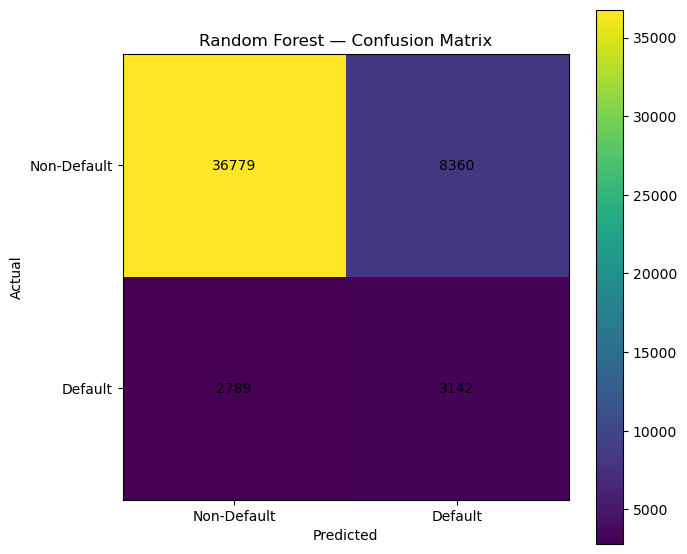

In [6]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Non-Default", "Default"]
)

plt.yticks(
    [0, 1],
    ["Non-Default", "Default"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [7]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

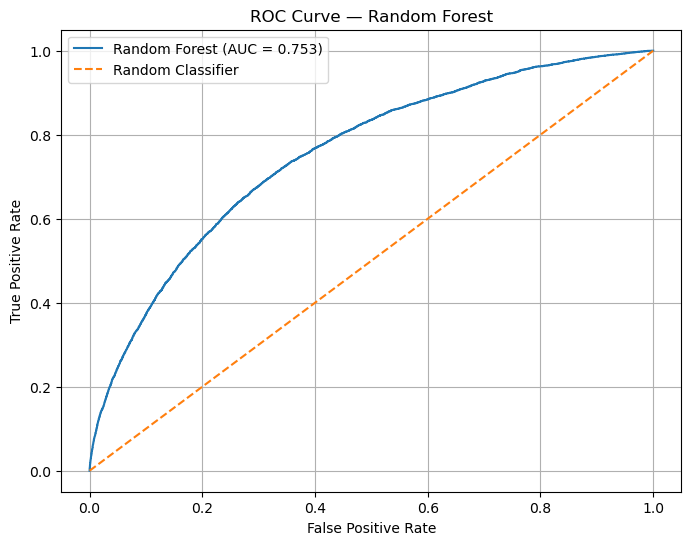

In [8]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Random Forest")

plt.legend()
plt.grid()

plt.show()

In [9]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

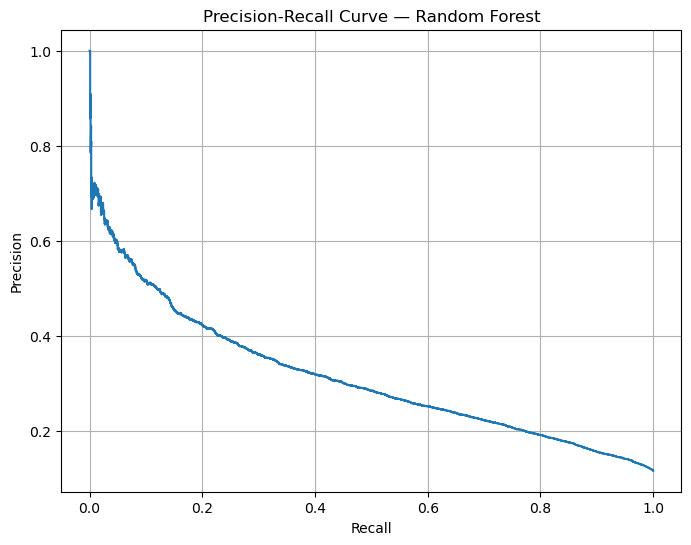

In [10]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve — Random Forest")

plt.grid()

plt.show()

In [11]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Non-Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

 Non-Default       0.93      0.81      0.87     45139
     Default       0.27      0.53      0.36      5931

    accuracy                           0.78     51070
   macro avg       0.60      0.67      0.61     51070
weighted avg       0.85      0.78      0.81     51070



In [ ]:
# 05_Model_Evaluation.ipynb

# 1. Imports
# 2. Load Final Model & Data
# 3. Final Performance Metrics
# 4. Confusion Matrix
# 5. ROC Curve
# 6. Precision-Recall Curve
# 7. Classification Report